<img src="images/banner.png" style="width: 100%;">

# Transfer learning

**MSDS 2026 | COSCI223: Machine Learning 3**

*Prepared by Kristine Ann M. Carandang*

## Setup

### Modules and Libraries

In [1]:
import os
import numpy as np
import pandas as pd

os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers
from keras.models import Sequential
from keras import models
from keras import regularizers
from keras.callbacks import EarlyStopping
from tensorflow import data as tf_data

from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 3})

In [2]:
def plot_history(history):
    """Generate the fitting history plot given the history object from
    model training

    Generates the training and validation accuracy and loss plots.

    Parameters
    ----------
    history : keras History object
        History object returned during model fitting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the generated validation and accuracy loss
        plots
    """
    # Get accuracies and losses from history object
    accuracy = history.history['accuracy']
    loss = history.history['loss']
    val_accuracy = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    # Generate epoch number list
    epochs = range(1, len(accuracy) + 1)

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot epochs and accuracy/loss values
    axes[0].plot(epochs, accuracy, 'o', color='tab:blue',
                 label='Train Accuracy')
    axes[0].plot(epochs, val_accuracy, '--', color='tab:blue',
                 label='Validation Accuracy')
    axes[1].plot(epochs, loss, 'o', color='tab:orange', label='Train Loss')
    axes[1].plot(epochs, val_loss, '--', color='tab:orange',
                 label='Validation Loss')

    # Add axis labels and legends
    for ax in axes:
        ax.set_xlabel("Epochs")
        ax.legend()
    axes[0].set_ylabel("Accuracy")
    axes[1].set_ylabel("Loss")
    fig.suptitle("Fitting History Plots", fontsize=16, weight='bold')

    return fig, axes

### Cats vs Dogs Dataset

We use this dataset, which is now stored locally under the directory `PetImages`. 

#### Creating the dataset

If you haven't created the dataset for this demonstration, perform the following steps (in jojie). If you're using your local pc, download the `train.zip` from https://www.kaggle.com/competitions/dogs-vs-cats/data then unzip `train.zip` then run the third code cell below:

In [ ]:
# !cp /mnt/data/public/kaggle/dogs_vs_cats/train.zip .

In [ ]:
# !unzip train.zip

In [ ]:
# import os, shutil, pathlib

# original_dir = pathlib.Path("train")
# new_base_dir = pathlib.Path("dogs_vs_cats_small")

# def make_subset(subset_name, start_index, end_index):
#     for category in ("cat", "dog"):
#         dir = new_base_dir / subset_name / category
#         os.makedirs(dir)
#         fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
#         for fname in fnames:
#             shutil.copyfile(src=original_dir / fname, dst=dir / fname)

# make_subset("train", start_index=0, end_index=1000)
# make_subset("validation", start_index=1000, end_index=1500)
# make_subset("test", start_index=1500, end_index=2500)

#### Load the dataset

In [3]:
# training parameters
batch_size = 8
n_epochs = 15

In [4]:
import pathlib

In [5]:
new_base_dir = pathlib.Path("dogs_vs_cats_small")

In [6]:
from keras.utils import image_dataset_from_directory

image_size = (180, 180)
train_dataset = image_dataset_from_directory(
    new_base_dir / "train", image_size=image_size, batch_size=batch_size
)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation", image_size=image_size, batch_size=batch_size
)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test", image_size=image_size, batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


**Visualize the data**

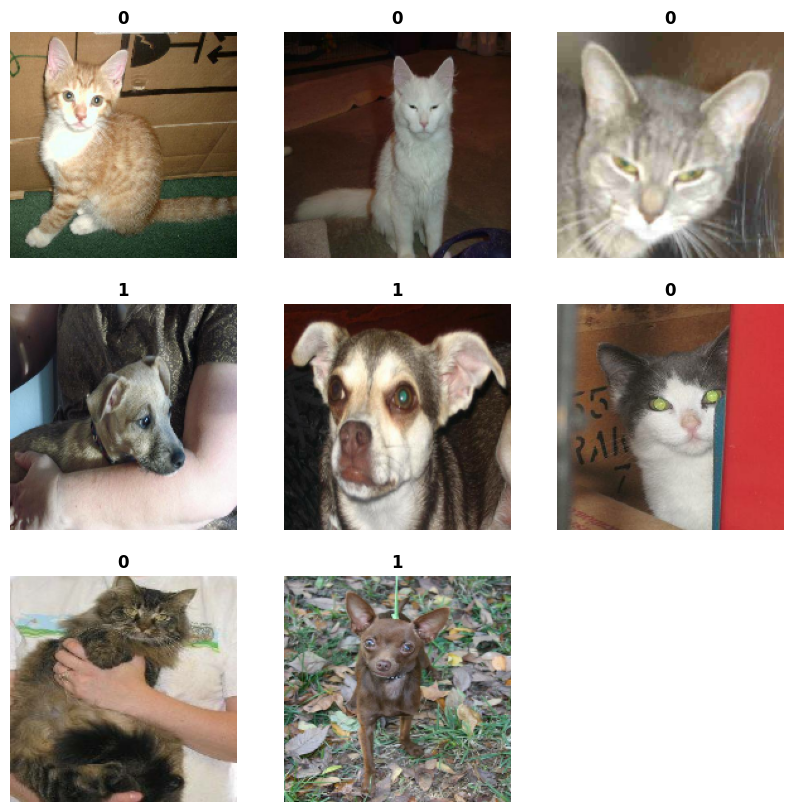

In [7]:
# Visualize the data
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(8):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## Pretrained Model
- [CNN Pretrained Models in Keras](https://keras.io/api/applications/)

A pretrained model is a model that was previously trained on a large dataset, typically on a large-scale image-classification task.

Below are examples of pre-trained CNN with their corresponding original papers:

1. AlexNet - [Imagenet classification with deep convolutional neural networks](https://dl.acm.org/doi/abs/10.1145/3065386)
2. VGG - [Very deep convolutional networks for large-scale image recognition](https://arxiv.org/abs/1409.1556)
3. DenseNet - [Densely Connected Convolutional Networks](https://arxiv.org/abs/1608.06993)
4. ResNet - [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385)
5. EfficientNet - [EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks](https://arxiv.org/abs/1905.11946)
6. MobileNet - [MobileNetV2: Inverted Residuals and Linear Bottlenecks](https://arxiv.org/abs/1801.04381)
7. MedNet - [MedNet: pre-trained convolutional neural network model for the medical imaging tasks](https://arxiv.org/abs/2110.06512)


### Load a pretrained model

For illustration purposes, we use [VGG16](https://arxiv.org/abs/1409.1556) as an example.

In [8]:
# Load pretrained model
vgg16 = keras.applications.VGG16(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    name="vgg16",
)

print(vgg16)

<Functional name=vgg16, built=True>


In [9]:
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

## Transfer learning approaches

### Pretrained model as a feature extractor

Feature extraction consists of using the representations learned by a previously trained model to extract interesting features from new samples. These features are then run through a new classifier, which is trained from scratch.

In [10]:
# !pip install keras-hub --upgrade

In [11]:
import keras_hub

conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet")

/home/llorenzo/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

#### Fast feature extraction

In [13]:
import numpy as np

In [14]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = preprocessor(images)
        features = conv_base.predict(preprocessed_images, verbose=0)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

In [15]:
train_features.shape

(2000, 6, 6, 2048)

In [17]:
inputs = keras.Input(shape=(6, 6, 2048))
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    train_features,
    train_labels,
    epochs=10,
    validation_data=(val_features, val_labels),
    callbacks=callbacks,
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9645 - loss: 0.0852 - val_accuracy: 0.9790 - val_loss: 0.0613
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9840 - loss: 0.0437 - val_accuracy: 0.9860 - val_loss: 0.0428
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9940 - loss: 0.0175 - val_accuracy: 0.9830 - val_loss: 0.0482
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9990 - loss: 0.0063 - val_accuracy: 0.9860 - val_loss: 0.0503
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9980 - loss: 0.0043 - val_accuracy: 0.9850 - val_loss: 0.0525
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9985 - loss: 0.0046 - val_accuracy: 0.9870 - val_loss: 0.0578
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9860 - val_loss: 0.0574
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9820 - v

(<Figure size 1600x500 with 2 Axes>,
 array([<Axes: xlabel='Epochs', ylabel='Accuracy'>,
        <Axes: xlabel='Epochs', ylabel='Loss'>], dtype=object))

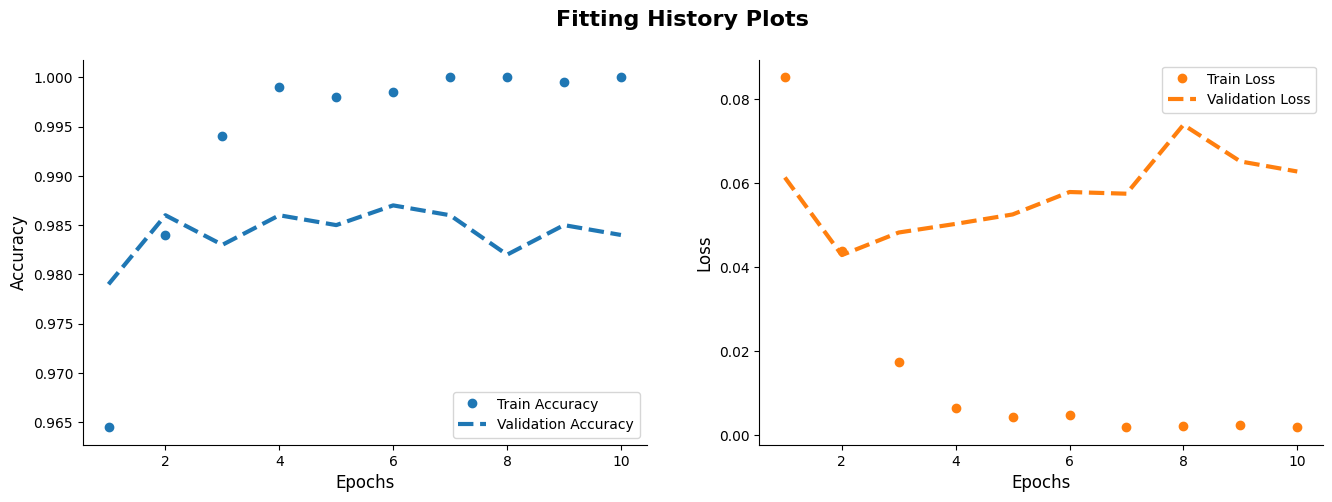

In [18]:
plot_history(history)

In [19]:
test_model = keras.models.load_model("feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9820 - loss: 0.0516
Test accuracy: 0.982


#### Slow feature extraction

In [20]:
import tensorflow as tf

In [21]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

def data_augmentation(images, targets):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

augmented_train_dataset = train_dataset.map(
    data_augmentation, num_parallel_calls=8
)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

In [22]:
import keras_hub

In [23]:
conv_base = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
    trainable=False,
)

In [24]:
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

In [25]:
inputs = keras.Input(shape=(180, 180, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [26]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction_with_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 59s 226ms/step - accuracy: 0.7105 - loss: 0.5676 - val_accuracy: 0.8050 - val_loss: 1.4553
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 231ms/step - accuracy: 0.7565 - loss: 0.5285 - val_accuracy: 0.7940 - val_loss: 0.4380
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 229ms/step - accuracy: 0.8530 - loss: 0.3950 - val_accuracy: 0.8940 - val_loss: 0.3675
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 228ms/step - accuracy: 0.8755 - loss: 0.3352 - val_accuracy: 0.9070 - val_loss: 0.2171
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 224ms/step - accuracy: 0.8790 - loss: 0.3158 - val_accuracy: 0.8620 - val_loss: 0.3067
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 223ms/step - accuracy: 0.8855 - loss: 0.3018 - val_accuracy: 0.8510 - val_loss: 0.4796
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 221ms/step - accuracy: 0.9025 - loss: 0.2516 - val_accuracy: 0.9090 - val_loss: 0.2522
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 220ms/step - accuracy: 0.9200 - loss: 0

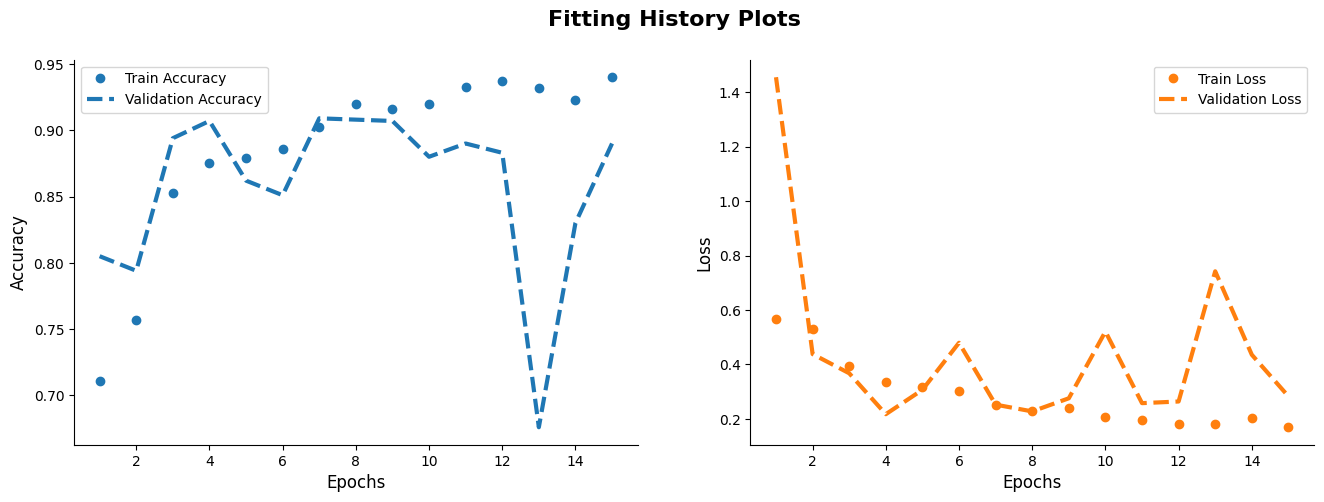

In [29]:
plot_history(history);

In [30]:
test_model = keras.models.load_model(
    "feature_extraction_with_data_augmentation.keras"
)
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.9090 - loss: 0.2611
Test accuracy: 0.909


### Pretrained model with fine-tuning

Fine-tuning consists of unfreezing the frozen model base used for feature extraction and jointly training both the newly added part of the model (in this case, the fully connected classifier) and the base model. This is called fine-tuning because it slightly adjusts the more abstract representations of the model being reused to make them more relevant for the problem at hand.

In [31]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [33]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.8970 - loss: 0.2801 - val_accuracy: 0.8930 - val_loss: 0.2902
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.9080 - loss: 0.2433 - val_accuracy: 0.8960 - val_loss: 0.2734
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.9170 - loss: 0.2275 - val_accuracy: 0.8970 - val_loss: 0.2609
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.9135 - loss: 0.2239 - val_accuracy: 0.9020 - val_loss: 0.2434
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 144ms/step - accuracy: 0.9125 - loss: 0.2249 - val_accuracy: 0.9070 - val_loss: 0.2296
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 145ms/step - accuracy: 0.9170 - loss: 0.2031 - val_accuracy: 0.9070 - val_loss: 0.2217
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 142ms/step - accuracy: 0.9330 - loss: 0.1782 - val_accuracy: 0.9080 - val_loss: 0.2122
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.9310 - loss: 0

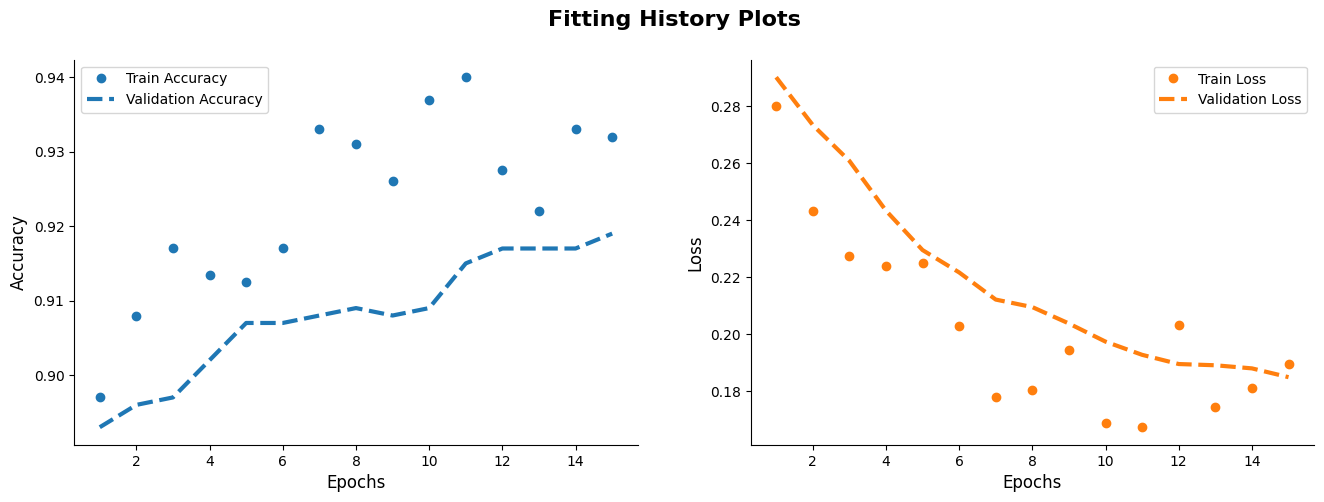

In [34]:
# Plot training-validation accuracy
plot_history(history);

In [35]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

/home2/llorenzo/.conda/new_envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 318 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 86ms/step - accuracy: 0.9175 - loss: 0.1952
Test accuracy: 0.918


<div class="alert alert-block alert-info"> 
<b>EXPLORATION TASK</b>
<br>
Try unfreezing more blocks, or blocks in the earlier layers. Note what happens.
<br>
Also try incorporating data augmentation.
<br>
</div>

## References

- Chollet, F., & Chollet, F. (2021). Deep learning with Python. simon and schuster.
- Bishop, C. M., & Bishop, H. (2023). Deep learning: Foundations and concepts. Springer Nature.
- Goodfellow, I., Bengio, Y., Courville, A., & Bengio, Y. (2016). Deep learning (Vol. 1, No. 2, pp. 1-800). Cambridge: MIT press.
- Monterola, CM. ML3 Notebook 2A.
- Simon, J. D. (2024). Understanding Deep Learning.

<img src="images/banner-down.png" style="width: 100%;">